In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from sklearn.model_selection import TimeSeriesSplit

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [6]:
from xgboost import XGBRegressor

In [8]:
df=pd.read_csv('../data/processed/combined_data.csv')

In [9]:
print(df.head(5))

    country      admin_1       market  latitude  longitude period_date  \
0  Ethiopia       Tigray      Abi Adi     13.56      38.97  2007-01-01   
1  Ethiopia       Tigray      Abi Adi     13.56      38.97  2007-01-01   
2  Ethiopia       Tigray      Abi Adi     13.56      38.97  2007-01-01   
3  Ethiopia       Amhara       Abomsa      9.98      39.98  2007-01-01   
4  Ethiopia  Addis Ababa  Addis Ababa      9.02      38.75  2007-01-01   

  currency  product   value  
0      ETB    maize  210.00  
1      ETB  sorghum    2.19  
2      ETB    wheat    3.79  
3      ETB    maize  110.00  
4      ETB    maize  156.00  


In [13]:
df['period_date']= pd.to_datetime(df['period_date'])

In [14]:
print(df.dtypes)

country                object
admin_1                object
market                 object
latitude              float64
longitude             float64
period_date    datetime64[ns]
currency               object
product                object
value                 float64
dtype: object


In [17]:
df = df.sort_values(
    ["market", "product","period_date"]
).reset_index(drop=True)

In [18]:
df['year']= df['period_date'].dt.year
df['month']= df['period_date'].dt.month
df['quarter']= df['period_date'].dt.quarter

In [21]:
df['lag1']= df.groupby(['market', 'product'])['value'].shift(1)
df['lag3']= df.groupby(['market', 'product'])['value'].shift(3)
df['lag6']= df.groupby(['market', 'product'])['value'].shift(6)
df['lag12']= df.groupby(['market', 'product'])['value'].shift(12)

In [22]:
print(df.head(15))

     country admin_1  market  latitude  longitude period_date currency  \
0   Ethiopia    Afar  Abaala     13.36      39.76  2020-01-01      ETB   
1   Ethiopia    Afar  Abaala     13.36      39.76  2020-02-01      ETB   
2   Ethiopia    Afar  Abaala     13.36      39.76  2023-02-01      ETB   
3   Ethiopia    Afar  Abaala     13.36      39.76  2023-08-01      ETB   
4   Ethiopia    Afar  Abaala     13.36      39.76  2024-05-01      ETB   
5   Ethiopia    Afar  Abaala     13.36      39.76  2024-06-01      ETB   
6   Ethiopia    Afar  Abaala     13.36      39.76  2024-07-01      ETB   
7   Ethiopia    Afar  Abaala     13.36      39.76  2024-08-01      ETB   
8   Ethiopia    Afar  Abaala     13.36      39.76  2024-09-01      ETB   
9   Ethiopia    Afar  Abaala     13.36      39.76  2024-10-01      ETB   
10  Ethiopia    Afar  Abaala     13.36      39.76  2025-01-01      ETB   
11  Ethiopia    Afar  Abaala     13.36      39.76  2025-02-01      ETB   
12  Ethiopia    Afar  Abaala     13.36

In [110]:
df["rolling_3"] = (
    df.groupby(["market", "product"])["value"]
      .transform(lambda x: x.shift(1).rolling(3).mean())
)

df["rolling_6"] = (
    df.groupby(["market", "product"])["value"]
      .transform(lambda x: x.shift(1).rolling(6).mean())
)

df["rolling_12"] = (
    df.groupby(["market", "product"])["value"]
      .transform(lambda x: x.shift(1).rolling(12).mean())
)

In [111]:
df.head(15)

,country,admin_1,market,latitude,longitude,period_date,currency,product,value,year,...,lag1,lag3,lag6,lag12,rolling_3,rolling_6,rolling_12,price_change_1,price_change_3,price_change_12
0,Ethiopia,SNNPR,Aroresa,6.22,39.02,2008-01-01,ETB,wheat,2.80,2008,...,3.50,3.00,2.60,2.00,NaN,NaN,NaN,-0.200000,-0.066667,0.400000
1,Ethiopia,Tigray,Mekele,13.50,39.48,2008-01-01,ETB,wheat,368.00,2008,...,375.00,360.00,357.00,275.00,NaN,NaN,NaN,-0.018667,0.022222,0.338182
2,Ethiopia,Oromia,Robe,7.13,40.00,2008-01-01,ETB,maize,233.00,2008,...,169.00,180.00,165.00,135.00,NaN,NaN,NaN,0.378698,0.294444,0.725926
3,Ethiopia,Oromia,Assela,7.95,39.13,2008-01-01,ETB,wheat,320.00,2008,...,312.00,317.00,296.00,164.00,NaN,NaN,NaN,0.025641,0.009464,0.951220
4,Ethiopia,Oromia,Merti,8.49,39.83,2008-01-01,ETB,sorghum,2.25,2008,...,2.10,1.70,2.00,1.80,NaN,NaN,NaN,0.071429,0.323529,0.250000
5,Ethiopia,Amhara,Baher Dar,11.60,37.38,2008-01-01,ETB,maize,220.00,2008,...,202.00,218.00,165.00,131.00,NaN,NaN,NaN,0.089109,0.009174,0.679389
6,Ethiopia,SNNPR,Sodo,6.85,37.75,2008-01-01,ETB,wheat,4.50,2008,...,4.40,3.91,2.80,2.80,NaN,NaN,NaN,0.022727,0.150895,0.607143
7,Ethiopia,SNNPR,Karati,5.25,37.48,2008-01-01,ETB,sorghum,2.30,2008,...,1.90,2.30,2.20,1.55,NaN,NaN,NaN,0.210526,0.000000,0.483871
8,Ethiopia,Somali,Gode,6.02,43.13,2008-01-01,ETB,sorghum,3.35,2008,...,2.69,2.55,2.20,1.20,NaN,NaN,NaN,0.245353,0.313725,1.791667
9,Ethiopia,Oromia,Jimma,7.67,36.83,2008-01-01,ETB,wheat,360.00,2008,...,360.00,358.00,294.00,300.00,NaN,NaN,NaN,0.000000,0.005587,0.200000


In [112]:
df['price_change_1']=df.groupby(['market', 'product'])['value'].pct_change(1)
df['price_change_3']=df.groupby(['market', 'product'])['value'].pct_change(3)
df['price_change_12']=df.groupby(['market', 'product'])['value'].pct_change(12)

In [113]:
df.head(15)

,country,admin_1,market,latitude,longitude,period_date,currency,product,value,year,...,lag1,lag3,lag6,lag12,rolling_3,rolling_6,rolling_12,price_change_1,price_change_3,price_change_12
0,Ethiopia,SNNPR,Aroresa,6.22,39.02,2008-01-01,ETB,wheat,2.80,2008,...,3.50,3.00,2.60,2.00,NaN,NaN,NaN,NaN,NaN,NaN
1,Ethiopia,Tigray,Mekele,13.50,39.48,2008-01-01,ETB,wheat,368.00,2008,...,375.00,360.00,357.00,275.00,NaN,NaN,NaN,NaN,NaN,NaN
2,Ethiopia,Oromia,Robe,7.13,40.00,2008-01-01,ETB,maize,233.00,2008,...,169.00,180.00,165.00,135.00,NaN,NaN,NaN,NaN,NaN,NaN
3,Ethiopia,Oromia,Assela,7.95,39.13,2008-01-01,ETB,wheat,320.00,2008,...,312.00,317.00,296.00,164.00,NaN,NaN,NaN,NaN,NaN,NaN
4,Ethiopia,Oromia,Merti,8.49,39.83,2008-01-01,ETB,sorghum,2.25,2008,...,2.10,1.70,2.00,1.80,NaN,NaN,NaN,NaN,NaN,NaN
5,Ethiopia,Amhara,Baher Dar,11.60,37.38,2008-01-01,ETB,maize,220.00,2008,...,202.00,218.00,165.00,131.00,NaN,NaN,NaN,NaN,NaN,NaN
6,Ethiopia,SNNPR,Sodo,6.85,37.75,2008-01-01,ETB,wheat,4.50,2008,...,4.40,3.91,2.80,2.80,NaN,NaN,NaN,NaN,NaN,NaN
7,Ethiopia,SNNPR,Karati,5.25,37.48,2008-01-01,ETB,sorghum,2.30,2008,...,1.90,2.30,2.20,1.55,NaN,NaN,NaN,NaN,NaN,NaN
8,Ethiopia,Somali,Gode,6.02,43.13,2008-01-01,ETB,sorghum,3.35,2008,...,2.69,2.55,2.20,1.20,NaN,NaN,NaN,NaN,NaN,NaN
9,Ethiopia,Oromia,Jimma,7.67,36.83,2008-01-01,ETB,wheat,360.00,2008,...,360.00,358.00,294.00,300.00,NaN,NaN,NaN,NaN,NaN,NaN


In [114]:
df=df.dropna().reset_index(drop=True)

In [115]:
df.isna().sum()

country            0
admin_1            0
market             0
latitude           0
longitude          0
period_date        0
currency           0
product            0
value              0
year               0
month              0
quarter            0
lag1               0
lag3               0
lag6               0
lag12              0
rolling_3          0
rolling_6          0
rolling_12         0
price_change_1     0
price_change_3     0
price_change_12    0
dtype: int64

In [116]:
df=df.sort_values("period_date").reset_index(drop=True)

In [117]:
X=df.drop(columns=['value', 'period_date'])
y=df['value']

In [118]:
print(X.head(5))

    country      admin_1       market  latitude  longitude currency product  \
0  Ethiopia       Oromia     Nazareth      8.55      39.27      ETB   wheat   
1  Ethiopia  Addis Ababa  Addis Ababa      9.02      38.75      ETB    teff   
2  Ethiopia       Oromia         Ambo      8.98      37.85      ETB   maize   
3  Ethiopia       Oromia     Nazareth      8.55      39.27      ETB   maize   
4  Ethiopia       Tigray        Korem     12.51      39.52      ETB   maize   

   year  month  quarter   lag1   lag3   lag6  lag12   rolling_3   rolling_6  \
0  2009      1        1  510.0  630.0  617.0  336.0  536.666667  603.333333   
1  2009      1        1  872.5  972.0  904.0  436.0  936.500000  933.083333   
2  2009      1        1  410.0  450.0  640.0  232.0  404.333333  518.388333   
3  2009      1        1  345.0  315.0  576.0  228.0  312.333333  428.791667   
4  2009      1        1  540.0  680.0  612.0  240.0  621.000000  635.833333   

   rolling_12  price_change_1  price_change_3  pri

In [119]:
tcsv=TimeSeriesSplit(n_splits=5)

In [120]:
for train_index, test_index in tcsv.split(X):
    print("Train Index:", train_index[0],"--",train_index[-1]) #-1 means last item
    print("Test Index:", test_index[0],"--",test_index[-1])

Train Index: 0 -- 4483
Test Index: 4484 -- 8967
Train Index: 0 -- 8967
Test Index: 8968 -- 13451
Train Index: 0 -- 13451
Test Index: 13452 -- 17935
Train Index: 0 -- 17935
Test Index: 17936 -- 22419
Train Index: 0 -- 22419
Test Index: 22420 -- 26903


In [121]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [122]:
categorical_features = ['country','admin_1','market','currency','product',]
numerical_features = [col for col in X.columns if col not in categorical_features]

In [123]:
print(categorical_features)

['country', 'admin_1', 'market', 'currency', 'product']


In [124]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [125]:
X_transformed = preprocessor.fit_transform(X)

In [126]:
X_transformed.shape

(26904, 137)

In [127]:
print(X_transformed)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 530540 stored elements and shape (26904, 137)>
  Coords	Values
  (0, 0)	1.0
  (0, 8)	1.0
  (0, 92)	1.0
  (0, 116)	1.0
  (0, 121)	1.0
  (0, 122)	8.55
  (0, 123)	39.27
  (0, 124)	2009.0
  (0, 125)	1.0
  (0, 126)	1.0
  (0, 127)	510.0
  (0, 128)	630.0
  (0, 129)	617.0
  (0, 130)	336.0
  (0, 131)	536.6666666666666
  (0, 132)	603.3333333333334
  (0, 133)	529.9233333333333
  (0, 134)	0.02941176470588225
  (0, 135)	-0.16666666666666663
  (0, 136)	0.5625
  (1, 0)	1.0
  (1, 1)	1.0
  (1, 14)	1.0
  (1, 116)	1.0
  (1, 120)	1.0
  :	:
  (26902, 131)	9108.333333333334
  (26902, 132)	8804.166666666666
  (26902, 133)	9331.25
  (26902, 135)	0.10144927536231885
  (26902, 136)	-0.01935483870967747
  (26903, 0)	1.0
  (26903, 8)	1.0
  (26903, 77)	1.0
  (26903, 116)	1.0
  (26903, 120)	1.0
  (26903, 122)	7.67
  (26903, 123)	36.83
  (26903, 124)	2026.0
  (26903, 125)	6.0
  (26903, 126)	2.0
  (26903, 127)	11283.33
  (26903, 128)	9525.0
  (26903, 129)	

In [128]:
from sklearn.pipeline import Pipeline

In [129]:
from sklearn.model_selection import RandomizedSearchCV

In [130]:
xgb_model = XGBRegressor(
    random_state=42
  
    )

In [131]:
para_dist={"n_estimators":[100, 200, 300, 400, 500],
           "max_depth":[3, 5, 6,8,10],
           "learning_rate":[0.01,0.02,0.05, 0.1, 0.2],
           "subsample":[0.6, 0.8,1.0],
           "colsample_bytree":[0.6,0.8,1.0]
           }

In [132]:
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=para_dist,
    n_iter=20,
    cv=tcsv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=42
)

In [133]:
random_search.fit(X_transformed,y)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.8, ...], 'learning_rate': [0.01, 0.02, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies

In [134]:
print(random_search.best_params_)

{'subsample': 0.6, 'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


In [135]:
best_model=random_search.best_estimator_

In [136]:
print(best_model)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=1.0, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)


In [137]:
df["period_date"].min(), df["period_date"].max()

(Timestamp('2009-01-01 00:00:00'), Timestamp('2026-06-01 00:00:00'))

In [138]:
split_date="2025-01-01"
train=df[df["period_date"]<split_date]
test=df[df["period_date"]>=split_date]

In [139]:
print(train.shape)
print(test.shape)

(25327, 22)
(1577, 22)


In [140]:
X_train= train.drop(columns=['value', 'period_date'])
y_train= train['value']

In [141]:
X_test= test.drop(columns=['value', 'period_date'])
y_test= test['value']

In [142]:
from sklearn.pipeline import Pipeline

final_pipline=  Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", best_model)
])

In [143]:
final_pipline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

In [144]:
y_pred=final_pipline.predict(X_test)

In [145]:
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [146]:
mae=mean_absolute_error(y_test, y_pred)
print("mean absolute error is = :", mae)

rmse=np.sqrt(mean_squared_error(y_test, y_pred))
print("root mean squared error is = :", rmse)

mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print("MAPE:", mape)

mean absolute error is = : 329.31776615556464
root mean squared error is = : 903.2657919893891
MAPE: 7.117606529857788


In [147]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
25327,8300.00,8048.413086
25328,5500.00,5337.528809
25329,3200.00,3249.190430
25330,9900.00,9932.605469
25331,6500.00,6602.870605
25332,7029.27,6914.495117
25333,6500.00,6381.403320
25334,4300.00,4298.487305
25335,4400.00,4391.280273
25336,3600.00,3575.878906


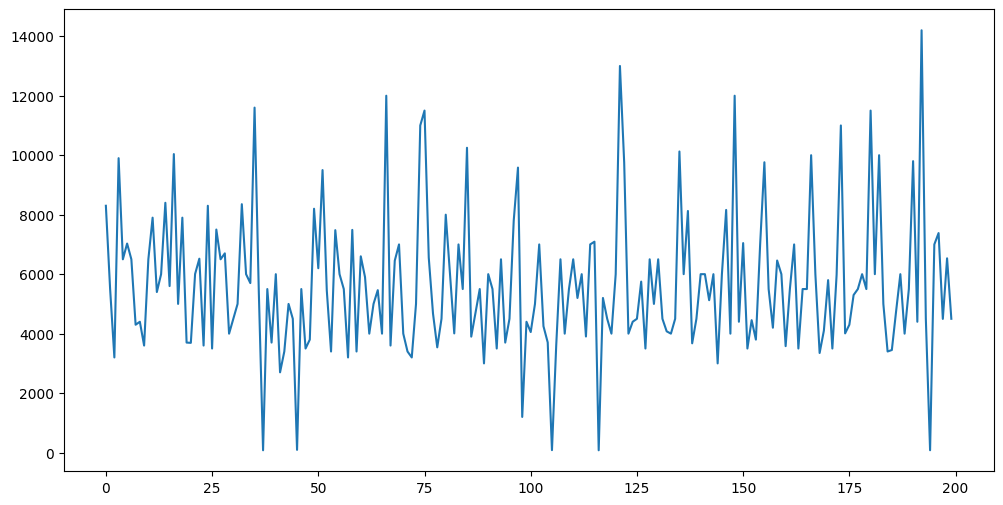

In [148]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values[:200],label="Actual")





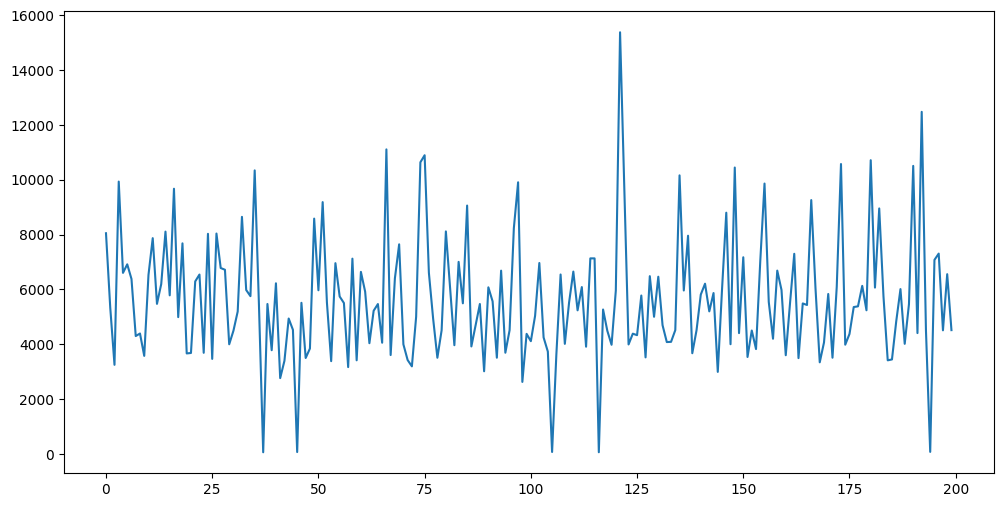

In [149]:

plt.figure(figsize=(12,6))
plt.plot(y_pred[:200],label="Predicted")






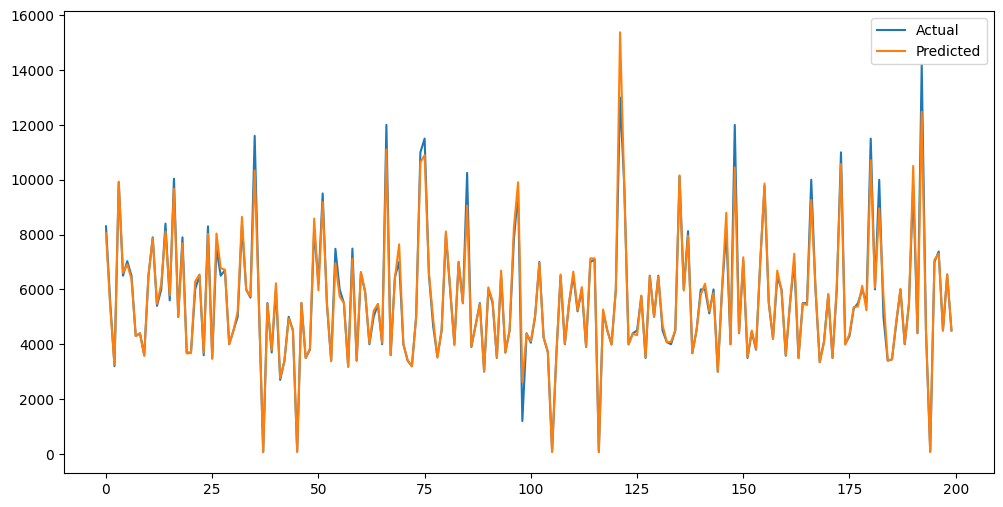

In [150]:
plt.figure(figsize=(12, 6))

# Ensure label is INSIDE the parenthesis
plt.plot(y_test.values[:200], label="Actual")
plt.plot(y_pred[:200], label="Predicted")

# Now legend will find the labels perfectly
plt.legend()
plt.show()



In [151]:
model = final_pipline.named_steps["model"]

In [152]:
feature_importance=model.feature_importances_
feature_names=final_pipline.named_steps["preprocessor"].get_feature_names_out()

importance_df=pd.DataFrame({"feature:":feature_names,"Importance":feature_importance})
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

In [154]:
importance_df.head(20)

,feature:,Importance
123,remainder__rolling_3,0.670834
5,cat__admin_1_Dire Dawa,0.104265
124,remainder__rolling_6,0.075719
119,remainder__lag1,0.051719
126,remainder__price_change_1,0.022155
127,remainder__price_change_3,0.016003
111,cat__product_sorghum,0.007008
121,remainder__lag6,0.004255
110,cat__product_maize,0.003989
34,cat__market_Beddenno,0.003968


In [155]:
from sklearn.metrics import r2_score

In [156]:
r2=r2_score(y_test,y_pred)
print(f"R² Score: {r2:.4f}")

R² Score: 0.9061


In [158]:
import joblib
joblib.dump(final_pipline,"commodity_price_forecasting_pipeline.pkl")

['commodity_price_forecasting_pipeline.pkl']

In [159]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results.to_csv(
    "prediction_results.csv",
    index=False
)